# Week 4: 算法设计范式与GPU化

## 分治、动态规划、贪心 —— 及其并行化

本周探讨三大算法设计范式在GPU上的并行化潜力：

| 范式 | GPU友好度 | 原因 |
|------|-----------|------|
| **分治 (Divide & Conquer)** | ⭐⭐⭐ | 子问题独立，天然并行 |
| **动态规划 (DP)** | ⭐⭐ | 有依赖，但可用Wavefront并行 |
| **贪心 (Greedy)** | ⭐ | 顺序依赖最强，最难并行 |

In [1]:
# ============ 中文字体配置（Colab 完整版）============
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request

# 0. 先清理旧设置
plt.rcdefaults()

font_name = "NotoSansSC.ttf"

# 1. 下载字体
urls = [
    "https://github.com/google/fonts/raw/main/ofl/notosanssc/NotoSansSC%5Bwght%5D.ttf",
    "https://github.com/googlefonts/noto-cjk/raw/main/Sans/Variable/TTF/NotoSansSC-VF.ttf",
]

if not os.path.exists(font_name) or os.path.getsize(font_name) < 100000:
    for i, url in enumerate(urls):
        try:
            print(f"尝试源 {i+1}...")
            urllib.request.urlretrieve(url, font_name)
            if os.path.getsize(font_name) > 100000:
                print(f"下载成功！{os.path.getsize(font_name)/1024/1024:.2f} MB")
                break
        except Exception as e:
            print(f"源 {i+1} 失败: {e}")

# 2. 注册字体
font_path = os.path.abspath(font_name)
fm.fontManager.addfont(font_path)

# 3. 设置全局（用正确的名字 "Noto Sans SC"）
plt.rcParams['font.sans-serif'] = ['Noto Sans SC']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体配置完成！")

尝试源 1...
下载成功！16.95 MB
✅ 中文字体配置完成！


In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

# 尝试导入CuPy
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print(f"GPU可用: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except ImportError:
    GPU_AVAILABLE = False
    print("CuPy不可用，将使用NumPy模拟")
    cp = np

GPU可用: NVIDIA L4


---
## 1. 主定理 (Master Theorem)

分析分治算法复杂度的强力工具：

对于递归式 $T(n) = aT(n/b) + f(n)$：

| 情况 | 条件 | 结论 |
|------|------|------|
| Case 1 | $f(n) = O(n^{\log_b a - \epsilon})$ | $T(n) = \Theta(n^{\log_b a})$ |
| Case 2 | $f(n) = \Theta(n^{\log_b a})$ | $T(n) = \Theta(n^{\log_b a} \log n)$ |
| Case 3 | $f(n) = \Omega(n^{\log_b a + \epsilon})$ | $T(n) = \Theta(f(n))$ |

### 经典例子：
- **Merge Sort**: $T(n) = 2T(n/2) + O(n)$ → $O(n \log n)$ (Case 2)
- **Binary Search**: $T(n) = T(n/2) + O(1)$ → $O(\log n)$ (Case 2)
- **Karatsuba乘法**: $T(n) = 3T(n/2) + O(n)$ → $O(n^{1.585})$ (Case 1)
- **Strassen矩阵乘法**: $T(n) = 7T(n/2) + O(n^2)$ → $O(n^{2.807})$ (Case 1)

---
## 2. 分治算法 GPU 并行化

分治算法的子问题**独立**，天然适合GPU并行！

### 2.1 Merge Sort: CPU递归 vs GPU层级并行

In [3]:
def merge_sort_cpu(arr):
    """CPU递归版Merge Sort"""
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = merge_sort_cpu(arr[:mid])
    right = merge_sort_cpu(arr[mid:])
    return merge(left, right)

def merge(left, right):
    """合并两个有序数组"""
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

# 测试正确性
test_arr = [64, 34, 25, 12, 22, 11, 90]
print(f"原数组: {test_arr}")
print(f"排序后: {merge_sort_cpu(test_arr.copy())}")

原数组: [64, 34, 25, 12, 22, 11, 90]
排序后: [11, 12, 22, 25, 34, 64, 90]


In [4]:
def merge_sort_gpu_layers(arr):
    """GPU层级并行Merge Sort

    思路：自底向上，每一层的所有合并操作并行执行
    """
    n = len(arr)
    d_arr = cp.asarray(arr, dtype=cp.float32)
    d_temp = cp.empty_like(d_arr)

    width = 1
    while width < n:
        # 每一层：所有宽度为width的子数组对并行合并
        num_merges = (n + 2 * width - 1) // (2 * width)

        for start in range(0, n, 2 * width):
            mid = min(start + width, n)
            end = min(start + 2 * width, n)

            # 使用argsort进行合并（GPU友好）
            left = d_arr[start:mid]
            right = d_arr[mid:end]
            merged = cp.concatenate([left, right])
            indices = cp.argsort(merged)
            d_temp[start:end] = merged[indices]

        d_arr, d_temp = d_temp, d_arr
        width *= 2

    return cp.asnumpy(d_arr) if GPU_AVAILABLE else d_arr

In [5]:
# 大规模 Merge Sort 性能对比
print("=" * 60)
print("Merge Sort: CPU递归 vs GPU层级 vs CuPy内置排序")
print("=" * 60)

sizes = [1000, 5000, 10000, 50000,100000,500000]
results_merge = {'size': [], 'cpu_recursive': [], 'gpu_layers': [], 'cupy_sort': []}

for n in sizes:
    arr = np.random.rand(n).astype(np.float32)
    results_merge['size'].append(n)

    # CPU递归（小规模测试，大规模会很慢）
    if n <= 100000:
        start = time.time()
        _ = merge_sort_cpu(arr.tolist())
        t_cpu = time.time() - start
    else:
        t_cpu = float('nan')  # 太慢，跳过
    results_merge['cpu_recursive'].append(t_cpu * 1000)

    # GPU层级并行
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    _ = merge_sort_gpu_layers(arr)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_gpu_layers = time.time() - start
    results_merge['gpu_layers'].append(t_gpu_layers * 1000)

    # CuPy内置排序（高度优化）
    d_arr = cp.asarray(arr)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    _ = cp.sort(d_arr)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_cupy = time.time() - start
    results_merge['cupy_sort'].append(t_cupy * 1000)

    print(f"n={n:>7}: CPU递归={t_cpu*1000:>8.2f}ms, GPU层级={t_gpu_layers*1000:>8.2f}ms, CuPy={t_cupy*1000:>6.2f}ms")

Merge Sort: CPU递归 vs GPU层级 vs CuPy内置排序
n=   1000: CPU递归=    1.71ms, GPU层级=  988.16ms, CuPy=  4.71ms
n=   5000: CPU递归=   10.79ms, GPU层级= 1066.41ms, CuPy=  0.22ms
n=  10000: CPU递归=   22.55ms, GPU层级= 2150.02ms, CuPy=  0.15ms
n=  50000: CPU递归=     nanms, GPU层级=10576.05ms, CuPy=  0.14ms
n= 100000: CPU递归=     nanms, GPU层级=21087.55ms, CuPy=  0.15ms
n= 500000: CPU递归=     nanms, GPU层级=104561.18ms, CuPy=  0.21ms


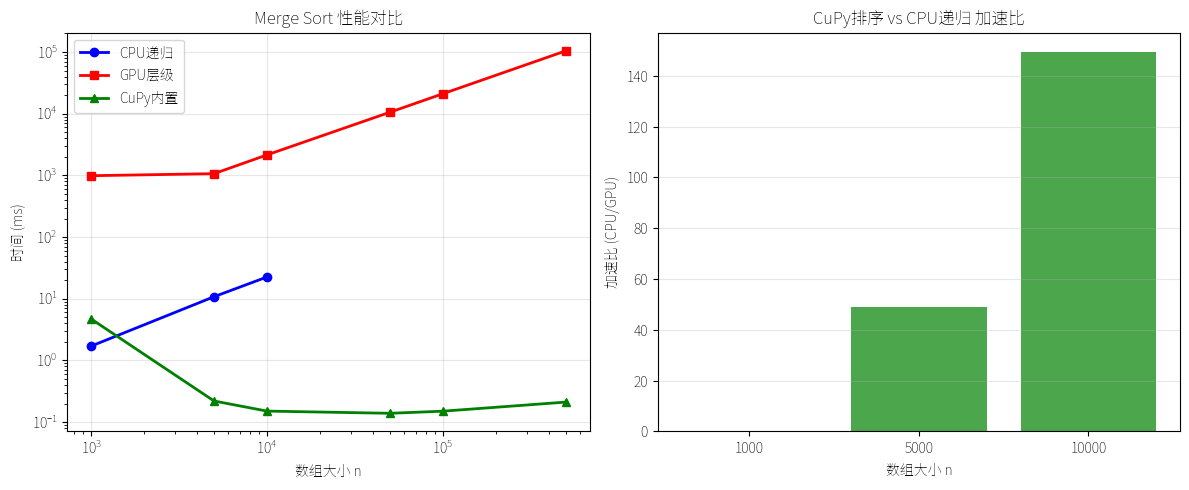

In [6]:
# 可视化 Merge Sort 性能对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_merge['size'], results_merge['cpu_recursive'], 'b-o', label='CPU递归', linewidth=2)
plt.plot(results_merge['size'], results_merge['gpu_layers'], 'r-s', label='GPU层级', linewidth=2)
plt.plot(results_merge['size'], results_merge['cupy_sort'], 'g-^', label='CuPy内置', linewidth=2)
plt.xlabel('数组大小 n')
plt.ylabel('时间 (ms)')
plt.title('Merge Sort 性能对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

plt.subplot(1, 2, 2)
# 计算加速比
speedup_cupy = [c/g if not np.isnan(c) else 0 for c, g in zip(results_merge['cpu_recursive'], results_merge['cupy_sort'])]
valid_sizes = [s for s, sp in zip(results_merge['size'], speedup_cupy) if sp > 0]
valid_speedup = [sp for sp in speedup_cupy if sp > 0]
plt.bar(range(len(valid_sizes)), valid_speedup, color='green', alpha=0.7)
plt.xticks(range(len(valid_sizes)), [str(s) for s in valid_sizes])
plt.xlabel('数组大小 n')
plt.ylabel('加速比 (CPU/GPU)')
plt.title('CuPy排序 vs CPU递归 加速比')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 2.2 Radix Sort: GPU的杀手级应用

**Radix Sort** 是**非比较排序**，特别适合GPU：
- 时间复杂度: $O(d \cdot n)$，其中 $d$ 是位数
- 每一轮的计数/分桶操作**完全并行**
- GPU上可达 **160x** 以上的加速比！

In [7]:
def radix_sort_cpu(arr):
    """CPU版Radix Sort (LSD)"""
    if len(arr) == 0:
        return arr

    max_val = max(arr)
    exp = 1
    output = arr.copy()

    while max_val // exp > 0:
        count = [0] * 10

        # 计数
        for num in output:
            index = (num // exp) % 10
            count[index] += 1

        # 累加
        for i in range(1, 10):
            count[i] += count[i - 1]

        # 输出
        result = [0] * len(arr)
        for i in range(len(arr) - 1, -1, -1):
            index = (output[i] // exp) % 10
            result[count[index] - 1] = output[i]
            count[index] -= 1

        output = result
        exp *= 10

    return output

def radix_sort_gpu(arr):
    """GPU版Radix Sort（使用CuPy的并行原语）"""
    if len(arr) == 0:
        return arr

    d_arr = cp.asarray(arr, dtype=cp.int32)
    max_val = int(cp.max(d_arr))

    exp = 1
    while max_val // exp > 0:
        # 提取当前位的数字
        digits = (d_arr // exp) % 10

        # 使用稳定排序按当前位排序
        indices = cp.argsort(digits, kind='stable')
        d_arr = d_arr[indices]

        exp *= 10

    return cp.asnumpy(d_arr) if GPU_AVAILABLE else d_arr

In [8]:
# Radix Sort 性能对比
print("=" * 60)
print("Radix Sort: CPU vs GPU")
print("=" * 60)

sizes_radix = [10000, 50000, 100000, 500000, 1000000, 5000000]
results_radix = {'size': [], 'cpu': [], 'gpu': [], 'speedup': []}

for n in sizes_radix:
    arr = np.random.randint(0, 10**6, n).astype(np.int32)
    results_radix['size'].append(n)

    # CPU Radix Sort
    if n <= 500000:
        start = time.time()
        _ = radix_sort_cpu(arr.tolist())
        t_cpu = time.time() - start
    else:
        t_cpu = float('nan')
    results_radix['cpu'].append(t_cpu * 1000)

    # GPU Radix Sort
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    _ = radix_sort_gpu(arr)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_gpu = time.time() - start
    results_radix['gpu'].append(t_gpu * 1000)

    speedup = t_cpu / t_gpu if not np.isnan(t_cpu) else 0
    results_radix['speedup'].append(speedup)

    print(f"n={n:>8}: CPU={t_cpu*1000:>10.2f}ms, GPU={t_gpu*1000:>8.2f}ms, 加速比={speedup:>6.1f}x")

Radix Sort: CPU vs GPU
n=   10000: CPU=     15.17ms, GPU=  522.25ms, 加速比=   0.0x
n=   50000: CPU=     80.58ms, GPU=    3.37ms, 加速比=  23.9x
n=  100000: CPU=    167.43ms, GPU=    4.50ms, 加速比=  37.2x
n=  500000: CPU=   1043.45ms, GPU=   19.91ms, 加速比=  52.4x
n= 1000000: CPU=       nanms, GPU=    9.15ms, 加速比=   0.0x
n= 5000000: CPU=       nanms, GPU=   46.88ms, 加速比=   0.0x


### 2.3 FFT: 蝴蝶操作的完美并行

FFT的蝴蝶结构天然适合GPU：每一层的蝴蝶操作**互相独立**！

In [9]:
# FFT 性能对比
print("=" * 60)
print("FFT: NumPy vs CuPy")
print("=" * 60)

sizes_fft = [2**10, 2**12, 2**14, 2**16, 2**18, 2**20, 2**22]
results_fft = {'size': [], 'cpu': [], 'gpu': [], 'speedup': []}

for n in sizes_fft:
    arr = np.random.rand(n).astype(np.complex64)
    results_fft['size'].append(n)

    # CPU FFT (NumPy)
    start = time.time()
    for _ in range(10):
        _ = np.fft.fft(arr)
    t_cpu = (time.time() - start) / 10
    results_fft['cpu'].append(t_cpu * 1000)

    # GPU FFT (CuPy)
    d_arr = cp.asarray(arr)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    for _ in range(10):
        _ = cp.fft.fft(d_arr)
        if GPU_AVAILABLE:
            cp.cuda.Stream.null.synchronize()
    t_gpu = (time.time() - start) / 10
    results_fft['gpu'].append(t_gpu * 1000)

    speedup = t_cpu / t_gpu
    results_fft['speedup'].append(speedup)

    print(f"n=2^{int(np.log2(n)):>2} ({n:>8}): CPU={t_cpu*1000:>8.3f}ms, GPU={t_gpu*1000:>8.3f}ms, 加速比={speedup:>6.1f}x")

FFT: NumPy vs CuPy
n=2^10 (    1024): CPU=   0.285ms, GPU=  22.729ms, 加速比=   0.0x
n=2^12 (    4096): CPU=   0.092ms, GPU=   6.441ms, 加速比=   0.0x
n=2^14 (   16384): CPU=   0.328ms, GPU=   8.336ms, 加速比=   0.0x
n=2^16 (   65536): CPU=   1.498ms, GPU=   0.283ms, 加速比=   5.3x
n=2^18 (  262144): CPU=   7.325ms, GPU=   0.098ms, 加速比=  75.1x
n=2^20 ( 1048576): CPU=  58.766ms, GPU=   0.135ms, 加速比= 436.2x
n=2^22 ( 4194304): CPU= 270.552ms, GPU=   0.687ms, 加速比= 393.7x


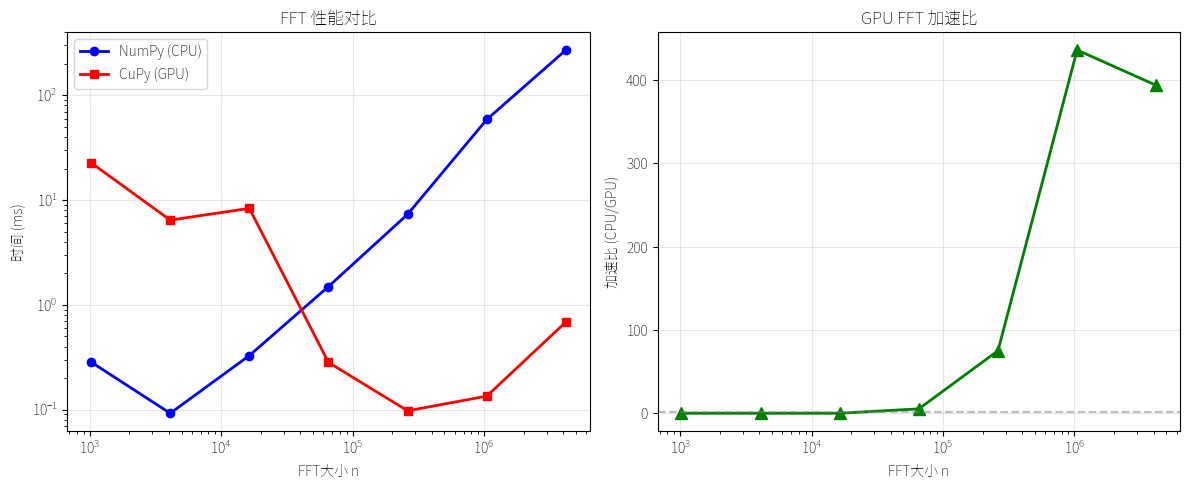

In [10]:
# FFT 可视化
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(results_fft['size'], results_fft['cpu'], 'b-o', label='NumPy (CPU)', linewidth=2)
plt.loglog(results_fft['size'], results_fft['gpu'], 'r-s', label='CuPy (GPU)', linewidth=2)
plt.xlabel('FFT大小 n')
plt.ylabel('时间 (ms)')
plt.title('FFT 性能对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(results_fft['size'], results_fft['speedup'], 'g-^', linewidth=2, markersize=8)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('FFT大小 n')
plt.ylabel('加速比 (CPU/GPU)')
plt.title('GPU FFT 加速比')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 动态规划 GPU 并行化: Wavefront 并行

DP的核心挑战：**依赖关系**

对于2D DP如 $dp[i][j] = f(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])$：

**关键洞察**：同一条反对角线上的元素**互相独立**！

```
    j=0  j=1  j=2  j=3
i=0  [0]  [1]  [2]  [3]   <- 对角线编号
i=1  [1]  [2]  [3]  [4]
i=2  [2]  [3]  [4]  [5]
i=3  [3]  [4]  [5]  [6]
```

### 3.1 编辑距离 (Edit Distance) GPU化

In [11]:
def edit_distance_cpu(A, B):
    """CPU版本：标准DP O(mn)"""
    m, n = len(A), len(B)
    dp = np.zeros((m+1, n+1), dtype=np.int32)
    dp[0, :] = np.arange(n+1)
    dp[:, 0] = np.arange(m+1)

    for i in range(1, m+1):
        for j in range(1, n+1):
            if A[i-1] == B[j-1]:
                dp[i, j] = dp[i-1, j-1]
            else:
                dp[i, j] = 1 + min(dp[i-1, j], dp[i, j-1], dp[i-1, j-1])
    return dp[m, n]

def edit_distance_gpu_wavefront(A, B):
    """GPU版本：对角线(Wavefront)并行"""
    m, n = len(A), len(B)

    # 转换为数值数组
    A_arr = cp.array([ord(c) for c in A], dtype=cp.int32)
    B_arr = cp.array([ord(c) for c in B], dtype=cp.int32)

    # DP表格
    dp = cp.zeros((m+1, n+1), dtype=cp.int32)
    dp[0, :] = cp.arange(n+1)
    dp[:, 0] = cp.arange(m+1)

    # 对角线并行：每条对角线 k = i + j
    for k in range(2, m + n + 1):
        # 当前对角线的有效范围
        i_start = max(1, k - n)
        i_end = min(m, k - 1)

        if i_start > i_end:
            continue

        # 构造索引
        i_indices = cp.arange(i_start, i_end + 1)
        j_indices = k - i_indices

        # 并行计算这条对角线上的所有元素
        match = (A_arr[i_indices - 1] == B_arr[j_indices - 1]).astype(cp.int32)

        candidates = cp.stack([
            dp[i_indices - 1, j_indices] + 1,      # 删除
            dp[i_indices, j_indices - 1] + 1,      # 插入
            dp[i_indices - 1, j_indices - 1] + (1 - match)  # 匹配/替换
        ])

        dp[i_indices, j_indices] = cp.min(candidates, axis=0)

    return int(dp[m, n])

In [12]:
# 编辑距离性能对比
print("=" * 60)
print("编辑距离: CPU DP vs GPU Wavefront")
print("=" * 60)

sizes_ed = [100, 500, 1000, 2000, 3000, 5000]
results_ed = {'size': [], 'cpu': [], 'gpu': [], 'speedup': []}

alphabet = list('ACGT')  # DNA序列

for size in sizes_ed:
    A = ''.join(np.random.choice(alphabet, size))
    B = ''.join(np.random.choice(alphabet, size))
    results_ed['size'].append(size)

    # CPU DP
    start = time.time()
    dist_cpu = edit_distance_cpu(A, B)
    t_cpu = time.time() - start
    results_ed['cpu'].append(t_cpu * 1000)

    # GPU Wavefront
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    dist_gpu = edit_distance_gpu_wavefront(A, B)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_gpu = time.time() - start
    results_ed['gpu'].append(t_gpu * 1000)

    speedup = t_cpu / t_gpu
    results_ed['speedup'].append(speedup)

    # 验证结果一致
    assert dist_cpu == dist_gpu, f"结果不一致! CPU={dist_cpu}, GPU={dist_gpu}"

    print(f"len={size:>5}: CPU={t_cpu*1000:>10.2f}ms, GPU={t_gpu*1000:>8.2f}ms, 加速比={speedup:>5.1f}x, 编辑距离={dist_cpu}")

编辑距离: CPU DP vs GPU Wavefront
len=  100: CPU=      8.14ms, GPU= 3249.56ms, 加速比=  0.0x, 编辑距离=60
len=  500: CPU=    205.07ms, GPU= 1207.33ms, 加速比=  0.2x, 编辑距离=269
len= 1000: CPU=    844.25ms, GPU= 2437.88ms, 加速比=  0.3x, 编辑距离=531
len= 2000: CPU=   3412.53ms, GPU= 4885.58ms, 加速比=  0.7x, 编辑距离=1047
len= 3000: CPU=   7734.00ms, GPU= 7381.66ms, 加速比=  1.0x, 编辑距离=1566
len= 5000: CPU=  21494.98ms, GPU=12317.70ms, 加速比=  1.7x, 编辑距离=2589


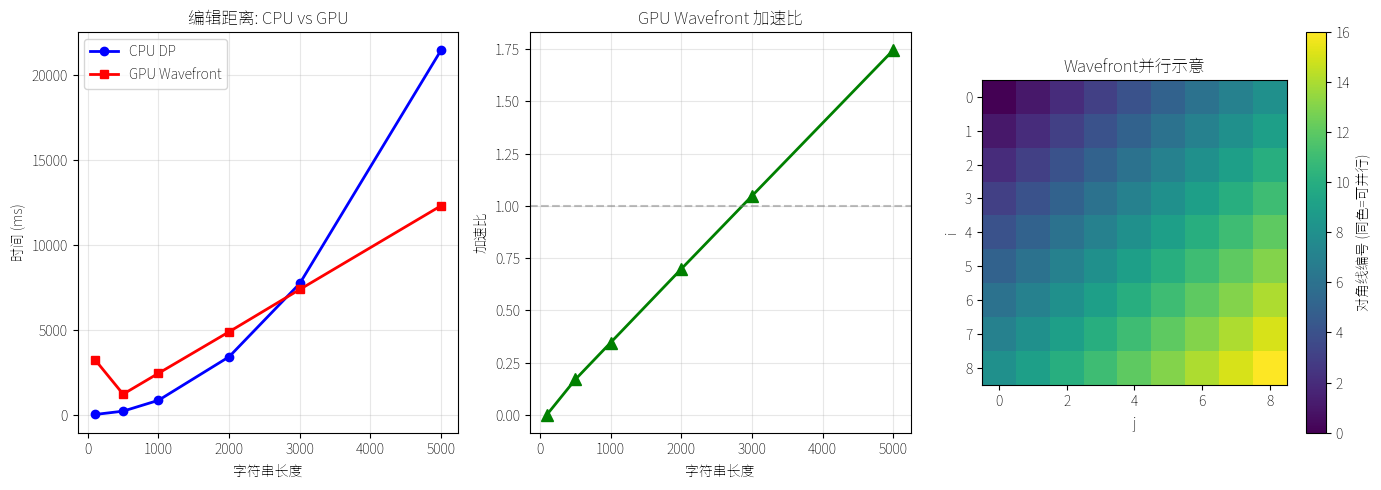

In [13]:
# 编辑距离可视化
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(results_ed['size'], results_ed['cpu'], 'b-o', label='CPU DP', linewidth=2)
plt.plot(results_ed['size'], results_ed['gpu'], 'r-s', label='GPU Wavefront', linewidth=2)
plt.xlabel('字符串长度')
plt.ylabel('时间 (ms)')
plt.title('编辑距离: CPU vs GPU')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(results_ed['size'], results_ed['speedup'], 'g-^', linewidth=2, markersize=8)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('字符串长度')
plt.ylabel('加速比')
plt.title('GPU Wavefront 加速比')
plt.grid(True, alpha=0.3)

# Wavefront并行可视化
plt.subplot(1, 3, 3)
m, n = 8, 8
diag_colors = np.zeros((m+1, n+1))
for i in range(m+1):
    for j in range(n+1):
        diag_colors[i, j] = i + j
plt.imshow(diag_colors, cmap='viridis', aspect='equal')
plt.colorbar(label='对角线编号 (同色=可并行)')
plt.xlabel('j')
plt.ylabel('i')
plt.title('Wavefront并行示意')

plt.tight_layout()
plt.show()

### 3.2 最长公共子序列 (LCS) GPU化

In [14]:
def lcs_cpu(A, B):
    """CPU版本LCS"""
    m, n = len(A), len(B)
    dp = np.zeros((m+1, n+1), dtype=np.int32)

    for i in range(1, m+1):
        for j in range(1, n+1):
            if A[i-1] == B[j-1]:
                dp[i, j] = dp[i-1, j-1] + 1
            else:
                dp[i, j] = max(dp[i-1, j], dp[i, j-1])
    return dp[m, n]

def lcs_gpu_wavefront(A, B):
    """GPU版本LCS: Wavefront并行"""
    m, n = len(A), len(B)

    A_arr = cp.array([ord(c) for c in A], dtype=cp.int32)
    B_arr = cp.array([ord(c) for c in B], dtype=cp.int32)

    dp = cp.zeros((m+1, n+1), dtype=cp.int32)

    for k in range(2, m + n + 1):
        i_start = max(1, k - n)
        i_end = min(m, k - 1)

        if i_start > i_end:
            continue

        i_indices = cp.arange(i_start, i_end + 1)
        j_indices = k - i_indices

        match = (A_arr[i_indices - 1] == B_arr[j_indices - 1])

        # LCS转移方程
        dp[i_indices, j_indices] = cp.where(
            match,
            dp[i_indices - 1, j_indices - 1] + 1,
            cp.maximum(dp[i_indices - 1, j_indices], dp[i_indices, j_indices - 1])
        )

    return int(dp[m, n])

In [15]:
# LCS性能对比
print("=" * 60)
print("LCS: CPU DP vs GPU Wavefront")
print("=" * 60)

for size in [500, 1000, 2000, 3000, 5000]:
    A = ''.join(np.random.choice(list('ABCD'), size))
    B = ''.join(np.random.choice(list('ABCD'), size))

    start = time.time()
    lcs_cpu_result = lcs_cpu(A, B)
    t_cpu = time.time() - start

    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    lcs_gpu_result = lcs_gpu_wavefront(A, B)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_gpu = time.time() - start

    assert lcs_cpu_result == lcs_gpu_result
    print(f"len={size:>5}: CPU={t_cpu*1000:>10.2f}ms, GPU={t_gpu*1000:>8.2f}ms, 加速比={t_cpu/t_gpu:>5.1f}x, LCS={lcs_cpu_result}")

LCS: CPU DP vs GPU Wavefront
len=  500: CPU=    158.11ms, GPU= 1273.35ms, 加速比=  0.1x, LCS=320
len= 1000: CPU=    638.53ms, GPU= 1951.07ms, 加速比=  0.3x, LCS=643
len= 2000: CPU=   2632.15ms, GPU= 3915.58ms, 加速比=  0.7x, LCS=1302
len= 3000: CPU=   6041.29ms, GPU= 5888.50ms, 加速比=  1.0x, LCS=1937
len= 5000: CPU=  16853.29ms, GPU= 9833.14ms, 加速比=  1.7x, LCS=3257


---
## 4. 贪心算法

贪心算法因为**顺序依赖**，是最难并行化的范式。

但我们可以：
1. **预处理并行化**（如排序）
2. **用GPU暴力替代贪心**（当规模较小时）

### 4.1 活动选择问题

选中的活动: [0, 3, 7, 10]
最大活动数: 4


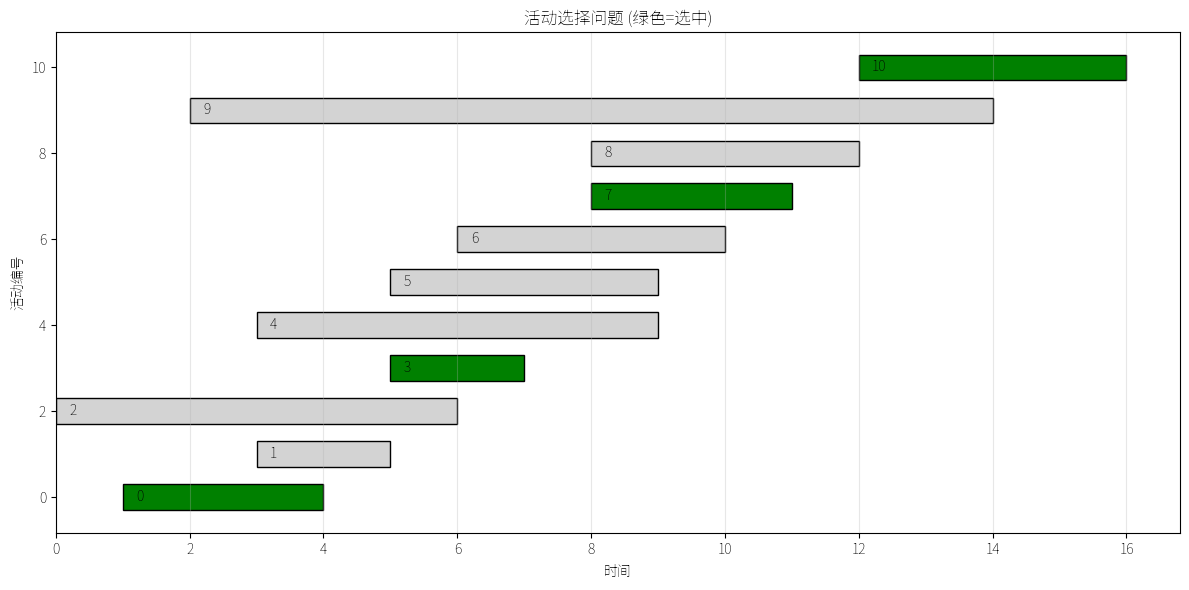

In [16]:
def activity_selection_greedy(starts, ends):
    """贪心算法：选择结束时间最早的活动"""
    n = len(starts)
    # 按结束时间排序
    indices = sorted(range(n), key=lambda i: ends[i])

    selected = [indices[0]]
    last_end = ends[indices[0]]

    for i in indices[1:]:
        if starts[i] >= last_end:
            selected.append(i)
            last_end = ends[i]

    return selected

# 示例
starts = [1, 3, 0, 5, 3, 5, 6, 8, 8, 2, 12]
ends =   [4, 5, 6, 7, 9, 9, 10, 11, 12, 14, 16]

selected = activity_selection_greedy(starts, ends)
print(f"选中的活动: {selected}")
print(f"最大活动数: {len(selected)}")

# 可视化
plt.figure(figsize=(12, 6))
for i in range(len(starts)):
    color = 'green' if i in selected else 'lightgray'
    plt.barh(i, ends[i] - starts[i], left=starts[i], height=0.6, color=color, edgecolor='black')
    plt.text(starts[i] + 0.2, i, f'{i}', va='center', fontsize=10)

plt.xlabel('时间')
plt.ylabel('活动编号')
plt.title('活动选择问题 (绿色=选中)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 4.2 霍夫曼编码

In [17]:
import heapq

class HuffmanNode:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

def build_huffman_tree(chars, freqs):
    """构建霍夫曼树"""
    heap = [HuffmanNode(c, f) for c, f in zip(chars, freqs)]
    heapq.heapify(heap)

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = HuffmanNode(None, left.freq + right.freq)
        merged.left = left
        merged.right = right

        heapq.heappush(heap, merged)

    return heap[0]

def get_codes(node, prefix="", codes=None):
    """从霍夫曼树提取编码"""
    if codes is None:
        codes = {}

    if node.char is not None:
        codes[node.char] = prefix or "0"
    else:
        if node.left:
            get_codes(node.left, prefix + "0", codes)
        if node.right:
            get_codes(node.right, prefix + "1", codes)

    return codes

# 示例
chars = ['a', 'b', 'c', 'd', 'e', 'f']
freqs = [45, 13, 12, 16, 9, 5]

root = build_huffman_tree(chars, freqs)
codes = get_codes(root)

print("霍夫曼编码:")
total_bits = 0
for char, freq in zip(chars, freqs):
    code = codes[char]
    bits = len(code) * freq
    total_bits += bits
    print(f"  {char}: freq={freq:>2}, code={code:<6}, bits={bits}")

avg_len = total_bits / sum(freqs)
print(f"\n平均编码长度: {avg_len:.2f} bits")
print(f"定长编码需要: 3 bits (log2(6)向上取整)")
print(f"节省: {(3 - avg_len) / 3 * 100:.1f}%")

霍夫曼编码:
  a: freq=45, code=0     , bits=45
  b: freq=13, code=101   , bits=39
  c: freq=12, code=100   , bits=36
  d: freq=16, code=111   , bits=48
  e: freq= 9, code=1101  , bits=36
  f: freq= 5, code=1100  , bits=20

平均编码长度: 2.24 bits
定长编码需要: 3 bits (log2(6)向上取整)
节省: 25.3%


### 4.3 0-1背包: DP vs 贪心(分数背包)

- **0-1背包**: 必须用DP，贪心不正确
- **分数背包**: 贪心正确（按单位价值排序）

In [18]:
def knapsack_01_dp(weights, values, capacity):
    """0-1背包 DP"""
    n = len(weights)
    dp = np.zeros((n+1, capacity+1), dtype=np.int32)

    for i in range(1, n+1):
        for w in range(capacity+1):
            if weights[i-1] <= w:
                dp[i, w] = max(dp[i-1, w], dp[i-1, w-weights[i-1]] + values[i-1])
            else:
                dp[i, w] = dp[i-1, w]

    return dp[n, capacity]

def fractional_knapsack_greedy(weights, values, capacity):
    """分数背包 贪心"""
    n = len(weights)
    # 按单位价值排序
    items = [(values[i]/weights[i], weights[i], values[i], i) for i in range(n)]
    items.sort(reverse=True)  # 单位价值从高到低

    total_value = 0
    remaining = capacity
    fractions = [0] * n

    for ratio, w, v, i in items:
        if remaining >= w:
            fractions[i] = 1.0
            total_value += v
            remaining -= w
        else:
            frac = remaining / w
            fractions[i] = frac
            total_value += v * frac
            break

    return total_value, fractions

# 示例
weights = [10, 20, 30]
values = [60, 100, 120]
capacity = 50

print("物品信息:")
for i in range(len(weights)):
    print(f"  物品{chr(65+i)}: 重量={weights[i]}, 价值={values[i]}, 单位价值={values[i]/weights[i]:.1f}")

print(f"\n背包容量: {capacity}")

dp_result = knapsack_01_dp(weights, values, capacity)
print(f"\n0-1背包 (DP): 最大价值 = {dp_result}")

greedy_value, fractions = fractional_knapsack_greedy(weights, values, capacity)
print(f"分数背包 (贪心): 最大价值 = {greedy_value}")
print(f"  取用比例: {[f'{f:.2f}' for f in fractions]}")

物品信息:
  物品A: 重量=10, 价值=60, 单位价值=6.0
  物品B: 重量=20, 价值=100, 单位价值=5.0
  物品C: 重量=30, 价值=120, 单位价值=4.0

背包容量: 50

0-1背包 (DP): 最大价值 = 220
分数背包 (贪心): 最大价值 = 240.0
  取用比例: ['1.00', '1.00', '0.67']


---
## 5. 暴力的逆袭：当并行改变一切

核心公式：$$\text{实际时间} = \frac{\text{总工作量}}{\text{并行度}}$$

当GPU有足够多核心时：
- $O(n^2)$ 并行 可能快于 $O(n)$ 串行！

### 5.1 Two Sum: 哈希 O(n) vs GPU暴力 O(n²)

In [19]:
def two_sum_hash(arr, target):
    """CPU哈希：O(n)但串行"""
    seen = {}
    for i, x in enumerate(arr):
        if target - x in seen:
            return (seen[target - x], i)
        seen[x] = i
    return None

def two_sum_gpu_brute(arr, target):
    """GPU暴力：O(n²)但并行"""
    d_arr = cp.asarray(arr)
    n = len(arr)

    # 创建所有配对的索引
    i_idx, j_idx = cp.triu_indices(n, k=1)

    # 并行检查所有配对
    sums = d_arr[i_idx] + d_arr[j_idx]
    matches = cp.where(sums == target)[0]

    if len(matches) > 0:
        idx = matches[0]
        return (int(i_idx[idx]), int(j_idx[idx]))
    return None

In [20]:
# Two Sum 性能对比
print("=" * 60)
print("Two Sum: 哈希 O(n) vs GPU暴力 O(n²)")
print("=" * 60)

sizes_ts = [100, 500, 1000, 2000, 5000, 10000, 20000]
results_ts = {'size': [], 'cpu_hash': [], 'gpu_brute': []}

for n in sizes_ts:
    arr = np.random.randint(0, n*10, n).astype(np.int64)
    target = int(arr[n//3] + arr[n//2])  # 保证有解
    results_ts['size'].append(n)

    # CPU哈希
    start = time.time()
    for _ in range(100):
        _ = two_sum_hash(arr.tolist(), target)
    t_cpu = (time.time() - start) / 100
    results_ts['cpu_hash'].append(t_cpu * 1000)

    # GPU暴力
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    for _ in range(100):
        _ = two_sum_gpu_brute(arr, target)
        if GPU_AVAILABLE:
            cp.cuda.Stream.null.synchronize()
    t_gpu = (time.time() - start) / 100
    results_ts['gpu_brute'].append(t_gpu * 1000)

    winner = "GPU" if t_gpu < t_cpu else "CPU"
    print(f"n={n:>6}: CPU哈希={t_cpu*1000:.3f}ms, GPU暴力={t_gpu*1000:.3f}ms, Winner: {winner}")

Two Sum: 哈希 O(n) vs GPU暴力 O(n²)
n=   100: CPU哈希=0.009ms, GPU暴力=14.359ms, Winner: CPU
n=   500: CPU哈希=0.027ms, GPU暴力=1.163ms, Winner: CPU
n=  1000: CPU哈希=0.047ms, GPU暴力=2.385ms, Winner: CPU
n=  2000: CPU哈希=0.071ms, GPU暴力=1.545ms, Winner: CPU
n=  5000: CPU哈希=0.184ms, GPU暴力=9.571ms, Winner: CPU
n= 10000: CPU哈希=0.309ms, GPU暴力=37.566ms, Winner: CPU
n= 20000: CPU哈希=0.498ms, GPU暴力=151.296ms, Winner: CPU


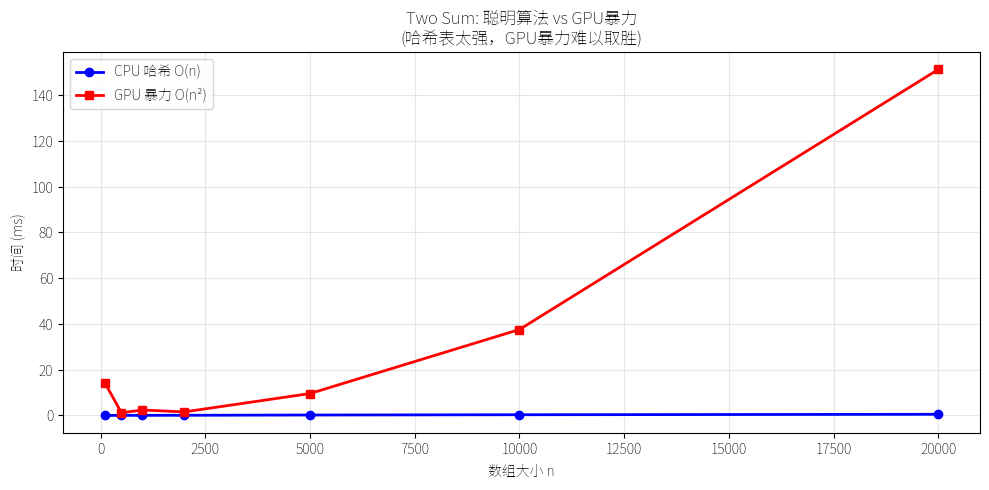

In [21]:
# Two Sum 可视化
plt.figure(figsize=(10, 5))

plt.plot(results_ts['size'], results_ts['cpu_hash'], 'b-o', label='CPU 哈希 O(n)', linewidth=2)
plt.plot(results_ts['size'], results_ts['gpu_brute'], 'r-s', label='GPU 暴力 O(n²)', linewidth=2)
plt.xlabel('数组大小 n')
plt.ylabel('时间 (ms)')
plt.title('Two Sum: 聪明算法 vs GPU暴力\n(哈希表太强，GPU暴力难以取胜)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# 极小规模测试，看 GPU 有没有一丝机会
import time
import numpy as np
import cupy as cp

sizes = [10, 20, 50, 100, 200]

for n in sizes:
    arr = np.random.randint(0, 1000, n).astype(np.int64)
    target = int(arr[0] + arr[1])

    # CPU 哈希
    start = time.time()
    for _ in range(1000):
        seen = {}
        for i, x in enumerate(arr):
            if target - x in seen:
                break
            seen[x] = i
    t_cpu = (time.time() - start) / 1000

    # GPU 暴力（预热后）
    arr_gpu = cp.array(arr)
    cp.cuda.Stream.null.synchronize()
    start = time.time()
    for _ in range(1000):
        i, j = cp.where(arr_gpu[:, None] + arr_gpu == target)
        cp.cuda.Stream.null.synchronize()
    t_gpu = (time.time() - start) / 1000

    print(f"n={n:>3}: CPU={t_cpu*1000:.4f}ms, GPU={t_gpu*1000:.4f}ms")

n= 10: CPU=0.0010ms, GPU=0.4267ms
n= 20: CPU=0.0010ms, GPU=0.2152ms
n= 50: CPU=0.0010ms, GPU=0.3684ms
n=100: CPU=0.0010ms, GPU=0.2376ms
n=200: CPU=0.0010ms, GPU=0.2366ms


### 5.2 最近点对: 分治 O(n log n) vs GPU暴力 O(n²)

In [22]:
def closest_pair_brute_cpu(points):
    """CPU暴力：O(n²)"""
    n = len(points)
    min_dist = float('inf')
    for i in range(n):
        for j in range(i+1, n):
            dist = np.sqrt((points[i][0]-points[j][0])**2 + (points[i][1]-points[j][1])**2)
            min_dist = min(min_dist, dist)
    return min_dist

def closest_pair_gpu_brute(points):
    """GPU暴力：O(n²)但完全并行"""
    points = cp.asarray(points)
    n = len(points)

    # 所有点对的索引
    i_idx, j_idx = cp.triu_indices(n, k=1)

    # 并行计算所有距离
    dx = points[i_idx, 0] - points[j_idx, 0]
    dy = points[i_idx, 1] - points[j_idx, 1]
    distances = cp.sqrt(dx**2 + dy**2)

    return float(cp.min(distances))

def closest_pair_scipy(points):
    """使用SciPy的KD树：O(n log n)"""
    from scipy.spatial import distance
    dists = distance.pdist(points)
    return np.min(dists)

In [23]:
# 最近点对 性能对比
print("=" * 60)
print("最近点对: CPU暴力 vs GPU暴力 vs SciPy优化")
print("=" * 60)

sizes_cp = [100, 500, 1000, 2000, 5000, 10000]
results_cp = {'size': [], 'cpu_brute': [], 'gpu_brute': [], 'scipy': []}

for n in sizes_cp:
    points = np.random.rand(n, 2).astype(np.float32)
    results_cp['size'].append(n)

    # CPU暴力
    if n <= 2000:
        start = time.time()
        _ = closest_pair_brute_cpu(points)
        t_cpu = time.time() - start
    else:
        t_cpu = float('nan')
    results_cp['cpu_brute'].append(t_cpu * 1000)

    # GPU暴力
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    _ = closest_pair_gpu_brute(points)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    t_gpu = time.time() - start
    results_cp['gpu_brute'].append(t_gpu * 1000)

    # SciPy
    start = time.time()
    _ = closest_pair_scipy(points)
    t_scipy = time.time() - start
    results_cp['scipy'].append(t_scipy * 1000)

    speedup = t_cpu / t_gpu if not np.isnan(t_cpu) else 0
    print(f"n={n:>6}: CPU暴力={t_cpu*1000:>10.2f}ms, GPU暴力={t_gpu*1000:>8.2f}ms, SciPy={t_scipy*1000:>8.2f}ms, CPU/GPU加速={speedup:>5.1f}x")

最近点对: CPU暴力 vs GPU暴力 vs SciPy优化
n=   100: CPU暴力=     12.97ms, GPU暴力=  561.50ms, SciPy=   22.43ms, CPU/GPU加速=  0.0x
n=   500: CPU暴力=    310.04ms, GPU暴力=    1.68ms, SciPy=    0.63ms, CPU/GPU加速=184.6x
n=  1000: CPU暴力=   1241.49ms, GPU暴力=    1.75ms, SciPy=    2.01ms, CPU/GPU加速=708.8x
n=  2000: CPU暴力=   4960.55ms, GPU暴力=    1.77ms, SciPy=    7.41ms, CPU/GPU加速=2809.7x
n=  5000: CPU暴力=       nanms, GPU暴力=   11.99ms, SciPy=   45.26ms, CPU/GPU加速=  0.0x
n= 10000: CPU暴力=       nanms, GPU暴力=   46.96ms, SciPy=  241.51ms, CPU/GPU加速=  0.0x


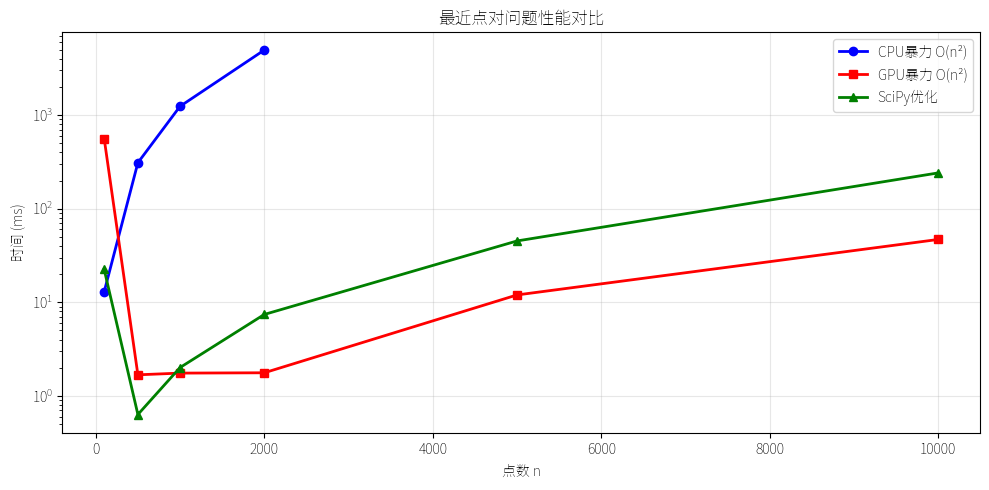

In [24]:
# 最近点对可视化
plt.figure(figsize=(10, 5))

plt.plot(results_cp['size'], results_cp['cpu_brute'], 'b-o', label='CPU暴力 O(n²)', linewidth=2)
plt.plot(results_cp['size'], results_cp['gpu_brute'], 'r-s', label='GPU暴力 O(n²)', linewidth=2)
plt.plot(results_cp['size'], results_cp['scipy'], 'g-^', label='SciPy优化', linewidth=2)
plt.xlabel('点数 n')
plt.ylabel('时间 (ms)')
plt.title('最近点对问题性能对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.3 矩阵乘法: 暴力 vs Strassen vs cuBLAS

In [25]:
def matmul_naive_cpu(A, B):
    """CPU朴素矩阵乘法 O(n³)"""
    n = A.shape[0]
    C = np.zeros((n, n), dtype=A.dtype)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i, j] += A[i, k] * B[k, j]
    return C

# 矩阵乘法性能对比
print("=" * 60)
print("矩阵乘法: CPU朴素 vs NumPy优化 vs GPU (cuBLAS)")
print("=" * 60)

sizes_mm = [64, 128, 256, 512, 1024, 2048]
results_mm = {'size': [], 'cpu_naive': [], 'numpy': [], 'gpu': []}

for n in sizes_mm:
    A = np.random.rand(n, n).astype(np.float32)
    B = np.random.rand(n, n).astype(np.float32)
    results_mm['size'].append(n)

    # CPU朴素（只测小规模）
    if n <= 128:
        start = time.time()
        _ = matmul_naive_cpu(A, B)
        t_naive = time.time() - start
    else:
        t_naive = float('nan')
    results_mm['cpu_naive'].append(t_naive * 1000)

    # NumPy (BLAS优化)
    start = time.time()
    for _ in range(10):
        _ = np.dot(A, B)
    t_numpy = (time.time() - start) / 10
    results_mm['numpy'].append(t_numpy * 1000)

    # GPU (cuBLAS)
    d_A = cp.asarray(A)
    d_B = cp.asarray(B)
    if GPU_AVAILABLE:
        cp.cuda.Stream.null.synchronize()
    start = time.time()
    for _ in range(10):
        _ = cp.dot(d_A, d_B)
        if GPU_AVAILABLE:
            cp.cuda.Stream.null.synchronize()
    t_gpu = (time.time() - start) / 10
    results_mm['gpu'].append(t_gpu * 1000)

    speedup = t_numpy / t_gpu
    print(f"n={n:>5}: CPU朴素={t_naive*1000:>10.2f}ms, NumPy={t_numpy*1000:>8.2f}ms, GPU={t_gpu*1000:>8.3f}ms, 加速比={speedup:>6.1f}x")

矩阵乘法: CPU朴素 vs NumPy优化 vs GPU (cuBLAS)
n=   64: CPU朴素=    153.97ms, NumPy=    0.30ms, GPU=  68.276ms, 加速比=   0.0x
n=  128: CPU朴素=   1228.35ms, NumPy=    0.46ms, GPU=   0.589ms, 加速比=   0.8x
n=  256: CPU朴素=       nanms, NumPy=    0.23ms, GPU=   0.063ms, 加速比=   3.7x
n=  512: CPU朴素=       nanms, NumPy=    0.88ms, GPU=   0.555ms, 加速比=   1.6x
n= 1024: CPU朴素=       nanms, NumPy=    4.56ms, GPU=   0.221ms, 加速比=  20.6x
n= 2048: CPU朴素=       nanms, NumPy=   28.76ms, GPU=   1.091ms, 加速比=  26.4x


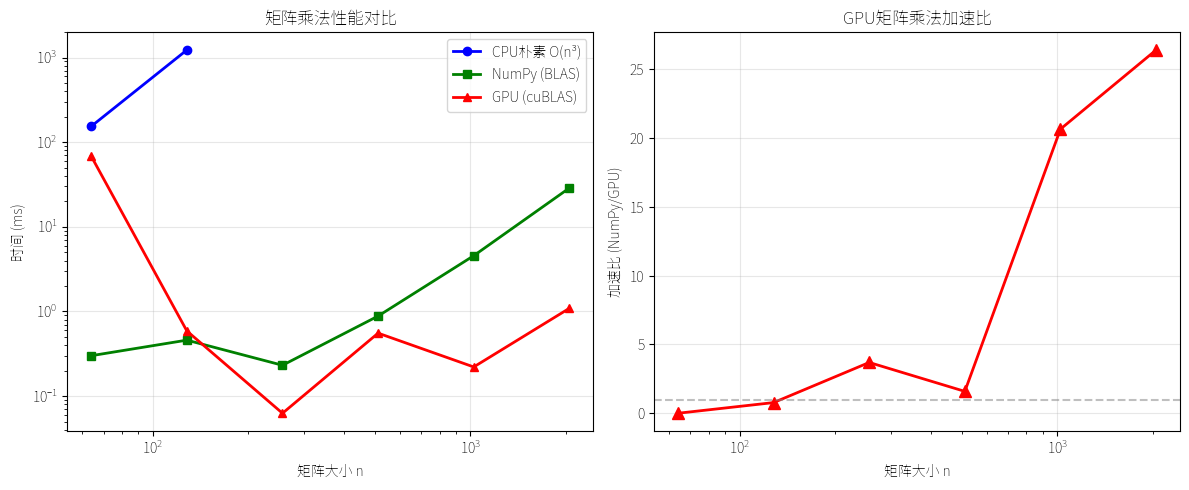

In [26]:
# 矩阵乘法可视化
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.loglog(results_mm['size'], results_mm['cpu_naive'], 'b-o', label='CPU朴素 O(n³)', linewidth=2)
plt.loglog(results_mm['size'], results_mm['numpy'], 'g-s', label='NumPy (BLAS)', linewidth=2)
plt.loglog(results_mm['size'], results_mm['gpu'], 'r-^', label='GPU (cuBLAS)', linewidth=2)
plt.xlabel('矩阵大小 n')
plt.ylabel('时间 (ms)')
plt.title('矩阵乘法性能对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
speedups = [n/g for n, g in zip(results_mm['numpy'], results_mm['gpu'])]
plt.semilogx(results_mm['size'], speedups, 'r-^', linewidth=2, markersize=8)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('矩阵大小 n')
plt.ylabel('加速比 (NumPy/GPU)')
plt.title('GPU矩阵乘法加速比')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. 综合性能总结

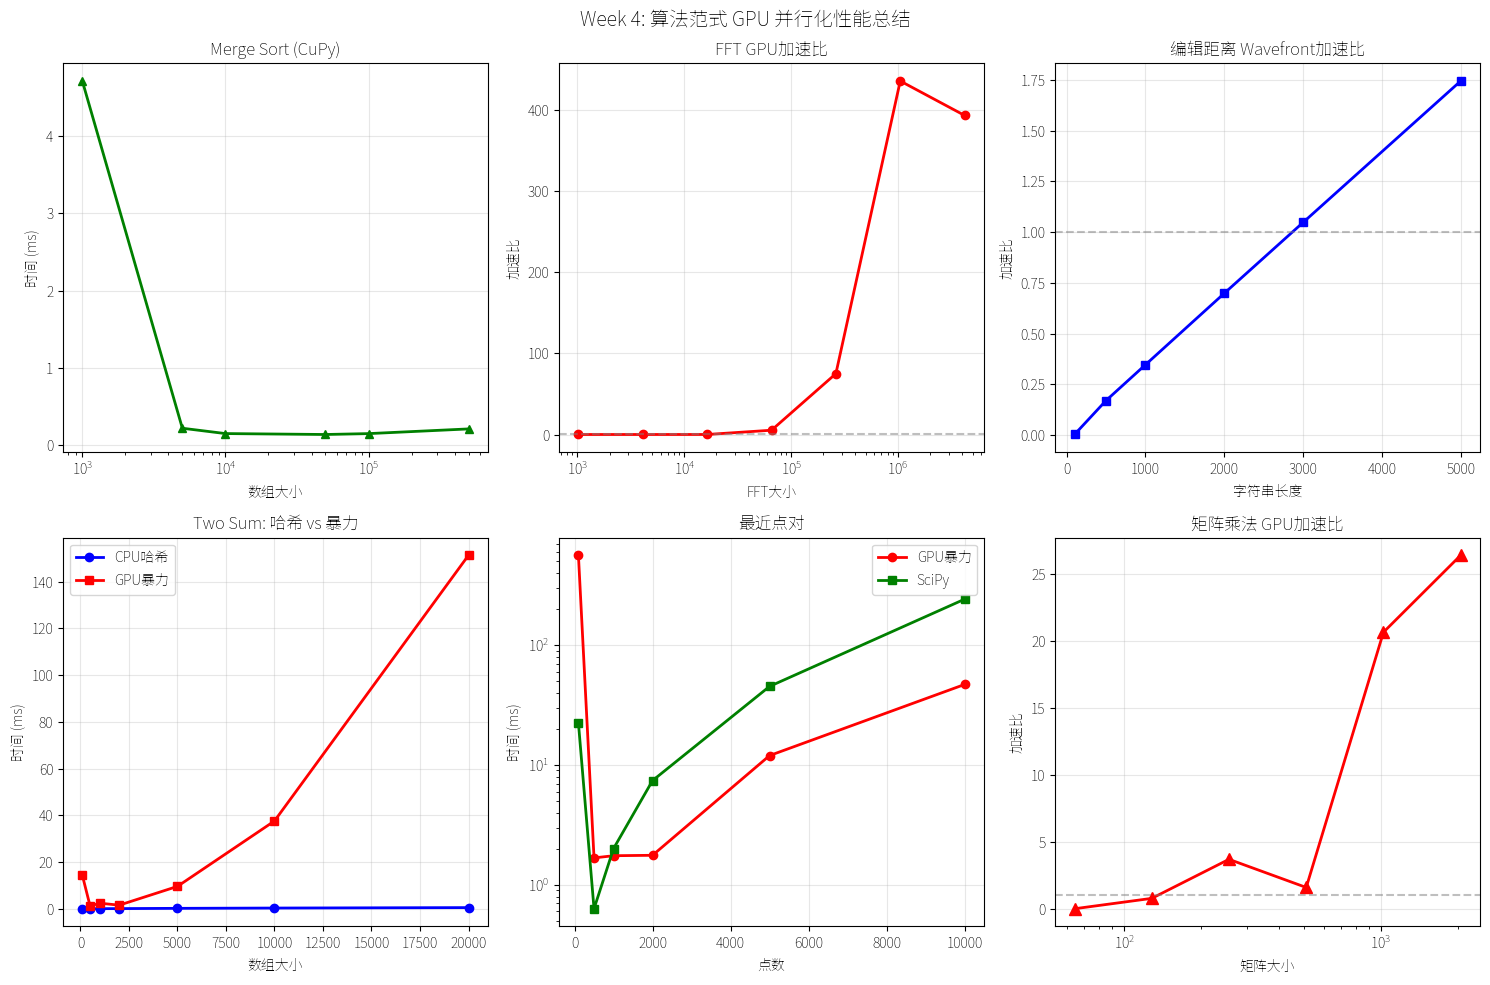

In [27]:
# 创建综合性能总结图
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Merge Sort
ax = axes[0, 0]
ax.plot(results_merge['size'], results_merge['cupy_sort'], 'g-^', linewidth=2)
ax.set_xlabel('数组大小')
ax.set_ylabel('时间 (ms)')
ax.set_title('Merge Sort (CuPy)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# 2. FFT
ax = axes[0, 1]
ax.semilogx(results_fft['size'], results_fft['speedup'], 'r-o', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('FFT大小')
ax.set_ylabel('加速比')
ax.set_title('FFT GPU加速比')
ax.grid(True, alpha=0.3)

# 3. 编辑距离
ax = axes[0, 2]
ax.plot(results_ed['size'], results_ed['speedup'], 'b-s', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('字符串长度')
ax.set_ylabel('加速比')
ax.set_title('编辑距离 Wavefront加速比')
ax.grid(True, alpha=0.3)

# 4. Two Sum
ax = axes[1, 0]
ax.plot(results_ts['size'], results_ts['cpu_hash'], 'b-o', label='CPU哈希', linewidth=2)
ax.plot(results_ts['size'], results_ts['gpu_brute'], 'r-s', label='GPU暴力', linewidth=2)
ax.set_xlabel('数组大小')
ax.set_ylabel('时间 (ms)')
ax.set_title('Two Sum: 哈希 vs 暴力')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. 最近点对
ax = axes[1, 1]
ax.plot(results_cp['size'], results_cp['gpu_brute'], 'r-o', label='GPU暴力', linewidth=2)
ax.plot(results_cp['size'], results_cp['scipy'], 'g-s', label='SciPy', linewidth=2)
ax.set_xlabel('点数')
ax.set_ylabel('时间 (ms)')
ax.set_title('最近点对')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# 6. 矩阵乘法
ax = axes[1, 2]
speedups_mm = [n/g for n, g in zip(results_mm['numpy'], results_mm['gpu'])]
ax.semilogx(results_mm['size'], speedups_mm, 'r-^', linewidth=2, markersize=8)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('矩阵大小')
ax.set_ylabel('加速比')
ax.set_title('矩阵乘法 GPU加速比')
ax.grid(True, alpha=0.3)

plt.suptitle('Week 4: 算法范式 GPU 并行化性能总结', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. 本周要点总结

### 三大算法范式的GPU化难度：

| 范式 | GPU友好度 | 并行策略 | 典型加速比 |
|------|-----------|----------|------------|
| **分治** | ⭐⭐⭐ | 子问题并行、层级并行 | 10-100x |
| **动态规划** | ⭐⭐ | Wavefront对角线并行 | 5-50x |
| **贪心** | ⭐ | 预处理并行，核心串行 | 1-5x |

### 关键洞察：

1. **分治天然并行**：独立子问题 → 直接并行
2. **DP可以Wavefront并行**：同一对角线上的元素互相独立
3. **贪心最难并行**：每步依赖前步结果
4. **暴力可能逆袭**：当 $O(n^2)$ 并行 > $O(n)$ 串行
5. **选择正确的算法**：有时"笨"算法在GPU上更快！